**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../data/processed', exist_ok=True)
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)
import xgboost as xgb
import joblib

RANDOM_STATE = 42

df = pd.read_csv('../data/processed/application_processed.csv')
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape} | Default rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  | Default rate: {y_test.mean():.2%}")

Train: (246008, 83) | Default rate: 8.07%
Test:  (61503, 83)  | Default rate: 8.07%


**Handle Class Imbalance**

In [2]:
# XGBoost uses scale_pos_weight instead of class_weight
# Formula: count(negative) / count(positive)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative (repaid)  : {neg:,}")
print(f"Positive (defaulted): {pos:,}")
print(f"scale_pos_weight   : {scale_pos_weight:.2f}")

Negative (repaid)  : 226,148
Positive (defaulted): 19,860
scale_pos_weight   : 11.39


**Train XGBoost Champion**

In [3]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.71464
[100]	validation_0-auc:0.76136
[200]	validation_0-auc:0.76689
[300]	validation_0-auc:0.76843
[373]	validation_0-auc:0.76859

Best iteration: 324


**Champion Metrics**

In [4]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred       = xgb_model.predict(X_test)

auc  = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ks   = max(tpr - fpr)
ap   = average_precision_score(y_test, y_pred_proba)

print("=" * 50)
print("XGBOOST CHAMPION — RESULTS")
print("=" * 50)
print(f"AUC-ROC  : {auc:.4f}  (baseline: 0.7476)")
print(f"Gini     : {gini:.4f}  (baseline: 0.4952)")
print(f"KS Stat  : {ks:.4f}  (baseline: 0.3665)")
print(f"PR-AUC   : {ap:.4f}  (baseline: 0.2288)")
print("=" * 50)
print(f"\nLift over baseline:")
print(f"  AUC  : +{auc  - 0.7476:.4f}")
print(f"  Gini : +{gini - 0.4952:.4f}")
print(f"  KS   : +{ks   - 0.3665:.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Repaid','Defaulted']))

XGBOOST CHAMPION — RESULTS
AUC-ROC  : 0.7689  (baseline: 0.7476)
Gini     : 0.5377  (baseline: 0.4952)
KS Stat  : 0.4059  (baseline: 0.3665)
PR-AUC   : 0.2578  (baseline: 0.2288)

Lift over baseline:
  AUC  : +0.0213
  Gini : +0.0425
  KS   : +0.0394
              precision    recall  f1-score   support

      Repaid       0.96      0.74      0.84     56538
   Defaulted       0.18      0.66      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



**Compare ROC curves: Baseline vs Champion**

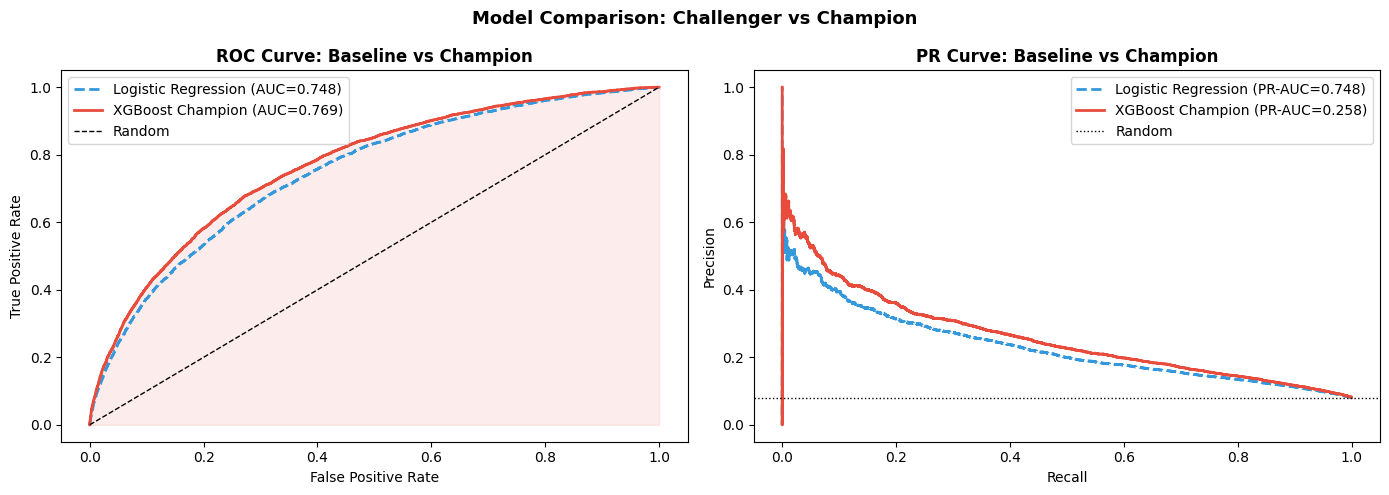

In [5]:
# Reload baseline predictions for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = joblib.load('../models/scaler.pkl')
lr     = joblib.load('../models/logistic_regression_baseline.pkl')

X_test_scaled    = scaler.transform(X_test)
lr_proba         = lr.predict_proba(X_test_scaled)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
lr_auc           = roc_auc_score(y_test, lr_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC comparison
axes[0].plot(lr_fpr, lr_tpr, color='#3498db', lw=2, linestyle='--',
             label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'XGBoost Champion (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Baseline vs Champion', fontweight='bold')
axes[0].legend()

# PR comparison
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
lr_prec, lr_rec, _   = precision_recall_curve(y_test, lr_proba)

axes[1].plot(lr_rec,  lr_prec,  color='#3498db', lw=2, linestyle='--',
             label=f'Logistic Regression (PR-AUC={lr_auc:.3f})')
axes[1].plot(recall, precision, color='#e74c3c', lw=2,
             label=f'XGBoost Champion (PR-AUC={ap:.3f})')
axes[1].axhline(y=y_test.mean(), color='k', linestyle=':', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve: Baseline vs Champion', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Comparison: Challenger vs Champion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/08_champion_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature Importance**

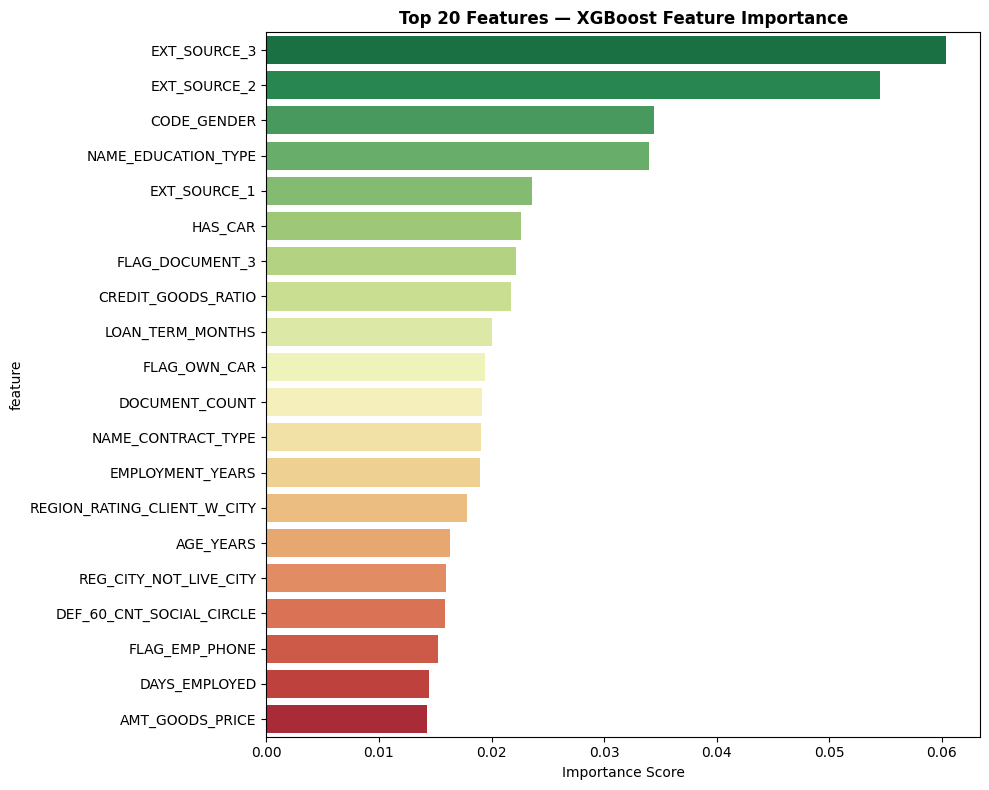

Top 10 features:
            feature  importance
       EXT_SOURCE_3    0.060359
       EXT_SOURCE_2    0.054456
        CODE_GENDER    0.034461
NAME_EDUCATION_TYPE    0.034021
       EXT_SOURCE_1    0.023592
            HAS_CAR    0.022659
    FLAG_DOCUMENT_3    0.022166
 CREDIT_GOODS_RATIO    0.021733
   LOAN_TERM_MONTHS    0.020037
       FLAG_OWN_CAR    0.019439


In [6]:
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='RdYlGn_r')
plt.title('Top 20 Features — XGBoost Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/09_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

**Save Champion Model**

In [7]:
joblib.dump(xgb_model, '../models/xgboost_champion.pkl')
print("Saved → models/xgboost_champion.pkl")

print("\n" + "=" * 50)
print("CHAMPION SUMMARY")
print("=" * 50)
print(f"Model     : XGBoost (n_estimators={xgb_model.best_iteration})")
print(f"AUC-ROC   : {auc:.4f}")
print(f"Gini      : {gini:.4f}")
print(f"KS Stat   : {ks:.4f}")
print(f"PR-AUC    : {ap:.4f}")
print("=" * 50)
print("Next: SHAP Explainability")

Saved → models/xgboost_champion.pkl

CHAMPION SUMMARY
Model     : XGBoost (n_estimators=324)
AUC-ROC   : 0.7689
Gini      : 0.5377
KS Stat   : 0.4059
PR-AUC    : 0.2578
Next: SHAP Explainability
